In [2]:
import json
import pandas as pd

with open("coffee_reviews.json", "r") as f:
    reviews = json.load(f)

print(len(reviews))
reviews[0]

5


{'timestamp': 1725000000,
 'details': [{'label': 'Rating', 'value': '5'},
  {'label': 'Comment', 'value': 'Best oat milk latte in town'},
  {'title': 'Reviewer',
   'dict': [{'dict': [{'label': 'Name', 'value': 'Alex Kim'},
      {'label': 'Username', 'value': 'alexk'}]}]}]}

In [3]:
pd.DataFrame(reviews)

,timestamp,details
0,1725000000,"[{'label': 'Rating', 'value': '5'}, {'label': ..."
1,1725003600,"[{'label': 'Rating', 'value': '3'}, {'label': ..."
2,1725010800,"[{'label': 'Rating', 'value': '4'}, {'label': ..."
3,1725014400,"[{'label': 'Rating', 'value': '2'}, {'label': ..."
4,1725018000,"[{'label': 'Rating', 'value': '5'}, {'label': ..."


In [4]:
type(reviews)

list

In [7]:

review["timestamp"]
review["details"]

[{'label': 'Rating', 'value': '5'},
 {'label': 'Comment', 'value': 'Best oat milk latte in town'},
 {'title': 'Reviewer',
  'dict': [{'dict': [{'label': 'Name', 'value': 'Alex Kim'},
     {'label': 'Username', 'value': 'alexk'}]}]}]

In [15]:
review["details"][2]

{'title': 'Reviewer',
 'dict': [{'dict': [{'label': 'Name', 'value': 'Alex Kim'},
    {'label': 'Username', 'value': 'alexk'}]}]}

In [11]:
def flatten_review(entry):
    row = {"timestamp": entry["timestamp"]}
    for item in entry["details"]:
        if "label" in item:
            row[item["label"].lower()] = item["value"]
        elif item.get("title") == "Reviewer":
            reviewer_fields = item["dict"][0]["dict"]
            for field in reviewer_fields:
                row["reviewer_" + field["label"].lower()] = field["value"]
    return row
flatten_review(reviews[0])

{'timestamp': 1725000000,
 'rating': '5',
 'comment': 'Best oat milk latte in town',
 'reviewer_name': 'Alex Kim',
 'reviewer_username': 'alexk'}

In [42]:



review["details"][2]["dict"][0]["dict"][1]["value"]


'jlee'

In [22]:
review["details"][2]["dict"][0]["dict"]

[{'label': 'Name', 'value': 'Alex Kim'},
 {'label': 'Username', 'value': 'alexk'}]

In [27]:
review["details"][2]["dict"][0]["dict"][0]["value"]

'Alex Kim'

In [25]:
review["details"][2]["dict"][0]["dict"][1]["value"]

'alexk'

In [28]:
rows = []
for review in reviews:
    row = {
        "timestamp": review["timestamp"],
        "rating": review["details"][0]["value"],
        "comment": review["details"][1]["value"],
        "reviewer_name": review["details"][2]["dict"][0]["dict"][0]["value"],
        "reviewer_username": review["details"][2]["dict"][0]["dict"][1]["value"]
    }
    rows.append(row)
    
df = pd.DataFrame(rows)
df.head()

,timestamp,rating,comment,reviewer_name,reviewer_username
0,1725000000,5,Best oat milk latte in town,Alex Kim,alexk
1,1725003600,3,A bit slow at lunch rush,Jordan Lee,jlee
2,1725010800,4,Great outdoor seating,Alex Kim,alexk
3,1725014400,2,Cold brew was watery,Sam Patel,spatel
4,1725018000,5,"Friendly staff, great music",Jordan Lee,jlee


In [44]:
df["date_time"] = pd.to_datetime(df["timestamp"], unit="s")
df.head()

,timestamp,rating,comment,reviewer_name,reviewer_username,date_time
0,2024-08-30 06:40:00,5,Best oat milk latte in town,Alex Kim,alexk,2024-08-30 06:40:00
1,2024-08-30 07:40:00,3,A bit slow at lunch rush,Jordan Lee,jlee,2024-08-30 07:40:00
2,2024-08-30 09:40:00,4,Great outdoor seating,Alex Kim,alexk,2024-08-30 09:40:00
3,2024-08-30 10:40:00,2,Cold brew was watery,Sam Patel,spatel,2024-08-30 10:40:00
4,2024-08-30 11:40:00,5,"Friendly staff, great music",Jordan Lee,jlee,2024-08-30 11:40:00


In [30]:
df.groupby("reviewer_username")["rating"].count()

reviewer_username
alexk     2
jlee      2
spatel    1
Name: rating, dtype: int64

In [31]:
df.groupby("rating")["comment"].count()

rating
2    1
3    1
4    1
5    2
Name: comment, dtype: int64

In [32]:
df.groupby("reviewer_username").count()

,timestamp,rating,comment,reviewer_name,date_time
reviewer_username,,,,,
alexk,2,2,2,2,2
jlee,2,2,2,2,2
spatel,1,1,1,1,1


Matplotlib is building the font cache; this may take a moment.


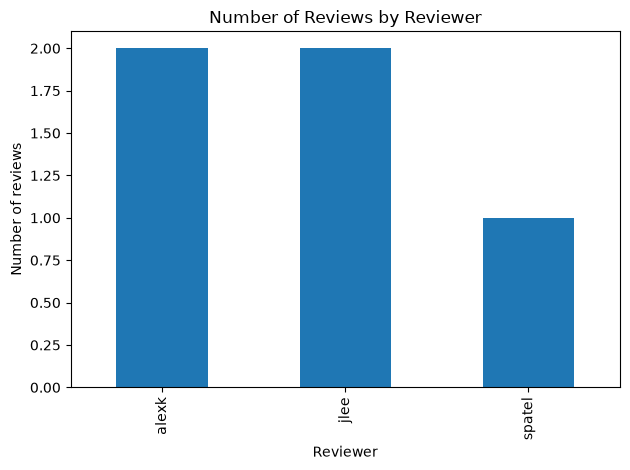

In [34]:
import matplotlib.pyplot as plt

reviewer_counts = df.groupby("reviewer_username")["rating"].count()

reviewer_counts.plot(kind="bar", title="Number of Reviews by Reviewer")
plt.xlabel("Reviewer")
plt.ylabel("Number of reviews")
plt.tight_layout()
plt.show()